In [3]:
import sys

path_to_pywrdrb = '../' #in notebook folder 
sys.path.append(path_to_pywrdrb)

In [4]:
from pywr.model import Model 
from pywrdrb.parameters import *
from pywrdrb.make_model import make_model

# Options: "nhmv10", "nwmv21", "nhmv10_withObsScaled", "nwmv21_withObsScaled" 
inflow_type = 'nwmv21_withObsScaled'   

model_filename = f'drb_model_full_{inflow_type}.json'
model_filepath = f'{path_to_pywrdrb}/pywrdrb/model_data/{model_filename}'

if inflow_type in ('nwmv21', 'nhmv10', 'WEAP_29June2023_gridmet') or 'withObsScaled' in inflow_type:
    start_date = '1983-10-01'
    end_date = '2016-12-31'

make_model(inflow_type=inflow_type,
           model_filename=model_filepath,
           start_date=start_date,
           end_date=end_date)

### load the pywrdrb model
model = Model.load(model_filepath)

In [5]:
### Read model parameter names into a list
model_parameters = [p for p in model.parameters if p.name]

print(f'There are {len(model_parameters)} parameters in the model')
# [output]: There are 394 parameters in the model

There are 454 parameters in the model


In [6]:
parameter_types = []

for parameter in model_parameters:
    parameter_type = str(type(parameter)).split('.')[-1][:-2]
    parameter_types.append(parameter_type)

print(parameter_types)


['FlowDelayParameter', 'FlowDelayParameter', 'FlowDelayParameter', 'FlowDelayParameter', 'FlowDelayParameter', 'FlowDelayParameter', 'FlowDelayParameter', 'FlowDelayParameter', 'FlowDelayParameter', 'FlowDelayParameter', 'FlowDelayParameter', 'FlowDelayParameter', 'FlowDelayParameter', 'FlowDelayParameter', 'FlowDelayParameter', 'ConstantParameter', 'ConstantParameter', 'ConstantParameter', 'AggregatedParameter', 'InterpolatedVolumeParameter', 'DataFrameParameter', 'ConstantParameter', 'DailyProfileParameter', 'DailyProfileParameter', 'DailyProfileParameter', 'DailyProfileParameter', 'DailyProfileParameter', 'DailyProfileParameter', 'ControlCurveIndexParameter', 'ConstantParameter', 'ConstantParameter', 'ConstantParameter', 'ConstantParameter', 'ConstantParameter', 'ConstantParameter', 'ConstantParameter', 'IndexedArrayParameter', 'AggregatedParameter', 'FfmpNycRunningAvgParameter', 'AggregatedParameter', 'DataFrameParameter', 'DataFrameParameter', 'DataFrameParameter', 'AggregatedPara

In [7]:
from collections import Counter

# Count occurrences of each parameter type
parameter_type_counts = Counter(parameter_types)

# Extract parameter types and their counts
types = list(parameter_type_counts.keys())
counts = list(parameter_type_counts.values())

print(types)
print(counts)

['FlowDelayParameter', 'ConstantParameter', 'AggregatedParameter', 'InterpolatedVolumeParameter', 'DataFrameParameter', 'DailyProfileParameter', 'ControlCurveIndexParameter', 'IndexedArrayParameter', 'FfmpNycRunningAvgParameter', 'NYCCombinedReleaseFactor', 'RollingMeanFlowNodeParameter', 'NYCFloodRelease', 'MonthlyProfileParameter', 'TotalReleaseNeededForDownstreamMRF', 'LowerBasinMaxMRFContribution', 'VolBalanceLowerBasinMRFAggregate', 'VolBalanceNYCDownstreamMRF_step1', 'LaggedReservoirRelease', 'VolBalanceNYCDownstreamMRF_step2', 'VolBalanceNYCDemand', 'VolBalanceLowerBasinMRFIndividual', 'STARFITReservoirRelease', 'FfmpNjRunningAvgParameter', 'ConstantScenarioParameter', 'FlowParameter']
[15, 138, 80, 7, 42, 27, 4, 10, 1, 3, 23, 3, 14, 6, 12, 4, 2, 10, 1, 3, 3, 14, 1, 1, 30]


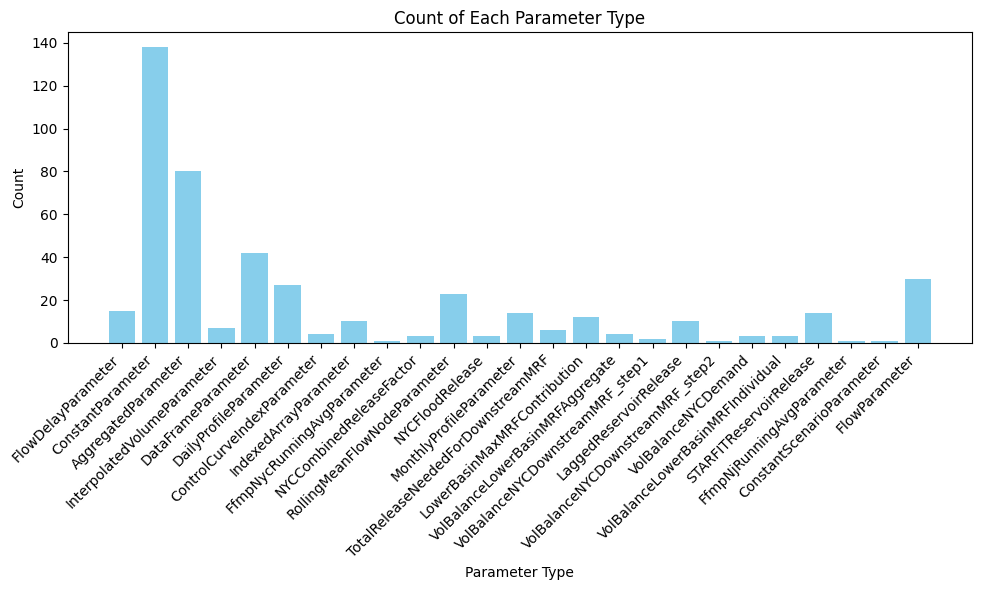

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(types, counts, color='skyblue')
plt.xlabel('Parameter Type')
plt.ylabel('Count')
plt.title('Count of Each Parameter Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


plt.show()